In [3]:
import imageio.v2 as iio
import imageio.v3 as iio3
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
from scipy.ndimage import generic_filter
from pathlib import Path
import pickle
from tqdm import tqdm

In [4]:
video_path = Path("data/ODEs/finger/real_finger/original_videos")
binary_path = Path("data/ODEs/finger/real_finger/binary_frames")
subsampled_path = Path("data/ODEs/finger/real_finger/subsampled_frames")
latents_path = Path("data/ODEs/finger/real_finger/latents")
pickle_path = Path("data/ODEs/finger/real_finger/pickle_files/shortened_real_finger_pos_time_1.5_ls_0.6_mean_22_var_4_scale_100.pkl")
pickle_path.parent.mkdir(parents=True, exist_ok=True)

In [44]:
def save_binary_video(original_video, binary_frames):
    fps = iio.get_reader(original_video, format="ffmpeg").get_meta_data()["fps"]
    out_video = binary_videos/f"{original_video.stem}.mp4"
    iio.mimsave(out_video, binary_frames, fps=fps)

In [47]:
def convert_to_binary(video):
    binary_frames = []
    for idx, frame in enumerate(iio3.imiter(video)):
        gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        gray_value = cv2.GaussianBlur(gray, (11,11), 0)            
        T, bw = cv2.threshold(gray_value, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        # flip = cv2.bitwise_not(bw)
        binary_frames.append(bw.astype(np.uint8))
    return binary_frames

In [48]:
for video in tqdm(list(video_path.glob("*.avi"))):
    print("Converting:", video.name)
    binary_frames = convert_to_binary(video)
    out_path = binary_path/f"{video.stem}.npy"
    np.save(out_path, np.stack(binary_frames))

Converting: video_15.avi
Converting: video_87.avi
Converting: video_53.avi
Converting: video_83.avi
Converting: video_98.avi
Converting: video_58.avi
Converting: video_79.avi
Converting: video_46.avi
Converting: video_54.avi
Converting: video_93.avi
Converting: video_17.avi
Converting: video_30.avi
Converting: video_32.avi
Converting: video_94.avi
Converting: video_38.avi
Converting: video_11.avi
Converting: video_88.avi
Converting: video_29.avi
Converting: video_74.avi
Converting: video_19.avi
Converting: video_86.avi
Converting: video_13.avi
Converting: video_21.avi
Converting: video_27.avi
Converting: video_52.avi
Converting: video_22.avi
Converting: video_26.avi
Converting: video_49.avi
Converting: video_1.avi
Converting: video_84.avi
Converting: video_42.avi
Converting: video_41.avi
Converting: video_73.avi
Converting: video_80.avi
Converting: video_62.avi
Converting: video_14.avi
Converting: video_64.avi
Converting: video_61.avi
Converting: video_66.avi
Converting: video_2.avi
Co

In [3]:
def subsample(frames, subsample_size):
    total_frames = len(frames)
    subsample_idx = np.linspace(0, total_frames-1, subsample_size).astype(int)
    return frames[subsample_idx]

In [92]:
def resize(binary_arr, scale=0.06):
    resized = []
    for frame in binary_arr:
        img = Image.fromarray(frame, mode='L')
        w, h = img.size
        img = img.resize((int(w * scale), int(h * scale)), Image.NEAREST)
        resized.append(np.array(img))
    return np.array(resized)

In [49]:
sum_frames = 0
for path in tqdm(list(binary_path.glob("*.npy"))):
    frame = np.load(path)
    sum_frames += (frame).astype(np.int32)
# plt.imshow(sum_frames)

100%|█████████████████████████████████████████| 100/100 [00:43<00:00,  2.29it/s]


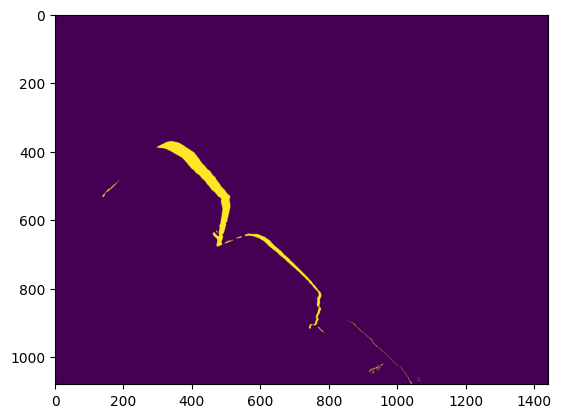

In [103]:
plt.imshow(sum_frames[97] - sum_frames[0] > 0 )

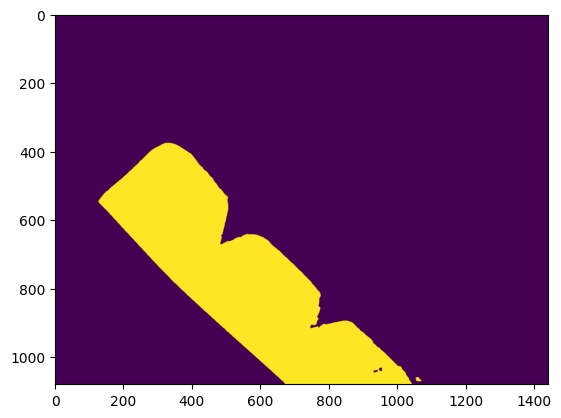

In [89]:
plt.imshow(sum_frames[80]>0)

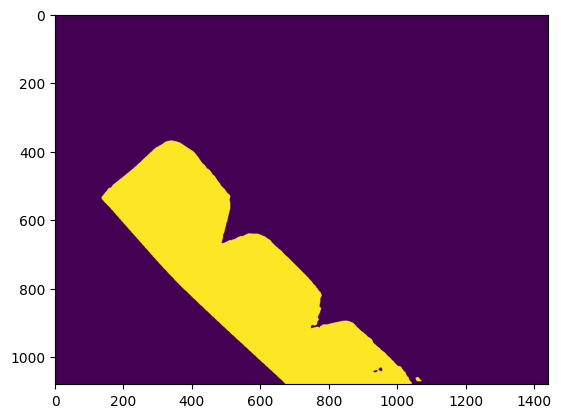

In [67]:
plt.imshow(sum_frames[100]>0)

In [93]:
# subsample_size = 600
for path in tqdm(list(binary_path.glob("*.npy"))):
    frames = np.load(path)
    shortened_frames = frames[80:]
    resized_frames = resize(shortened_frames)
    out_path = subsampled_path/path.name
    np.save(out_path, resized_frames)

100%|█████████████████████████████████████████| 100/100 [00:09<00:00, 10.69it/s]


In [106]:
frame_files = sorted(subsampled_path.glob("*.npy"))
latent_files = sorted(latents_path.glob("*.npy"))
frames = []
latents = []
for frame, latent in zip(frame_files, latent_files):
    frames.append(np.load(frame))
    latents.append(np.load(latent))

In [109]:
with open(pickle_path, "wb") as f:
    pickle.dump(
        dict(
            frames = np.stack(frames),
            latents = np.stack(latents),
            dt = time / num_frames,
            subsample = 1000,
            time = time,
            height = frames[0].shape[1],
            width = frames[0].shape[2]
        ), f
    )

In [28]:
def save_npy_video(npy_path, out_path, fps=20):
    frames = np.load(npy_path)
    if frames.dtype != np.uint8:
        frames = (frames * 255).clip(0, 255).astype(np.uint8)
    if len(frames.shape) == 3:  # (num_frames, H, W)
        frames = np.expand_dims(frames, -1)
    if frames.shape[-1] == 1:
        frames = np.repeat(frames, 3, axis=-1)
    iio.mimsave(out_path, frames, fps=fps)
    # print(f"Saved video to: {out_path}")

In [17]:
def save_npy_frames(npy_path, out_dir):
    frames = np.load(npy_path)
    print(len(frames))
    if frames.dtype != np.uint8:
        frames = (frames * 255).clip(0, 255).astype(np.uint8)
    if frames.ndim == 3:   
        pass
    elif frames.ndim == 2: 
        frames = frames[None, :, :]
    else:
        raise ValueError(f"Unexpected shape {frames.shape}")
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    for i, frame in enumerate(frames):
        if frame.ndim == 2:
            frame = np.repeat(frame[:, :, None], 3, axis=-1)
        fname = out_dir / f"frame_{i:04d}.png"
        iio.imwrite(fname, frame)
    # print(f"Saved {len(frames)} frames to {out_dir}")

In [25]:
npy_file = Path("data/ODEs/finger/real_finger/binary_frames/video_0.npy")
out_video = Path("data/ODEs/finger/real_finger/video_2_test.mp4")
out_dir  = "data/ODEs/finger/real_finger/video_9_frames"
save_npy_video(npy_file, out_video, fps=400)
save_npy_frames(npy_file, out_dir)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1440, 1080) to (1440, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x1ebf6080] Stream #0: not enough frames to estimate rate; consider increasing probesize


291



KeyboardInterrupt

